# STREAMLIT PARTE 2

### Aula 1:
- Apresentação do dataset
- Apresentação da ferramenta final

### Aula 2:
- Parte 1:
    - 1 coluna como filtro
    - st.set_page_config()
    - st.image()
    - st.slider()
    - st.pyplot()
- Parte 2:
    - 2 colunas como filtro
    - st.multiselect()
- Parte 3:
    - st.form()
    - st.form_submit_button()
    - sns.set_theme()

### Aula 3:
- 9 colunas como filtro


### Aula 4:
- pip install --upgrade streamlit
- pip install --upgrade matplotlib
- st.cache()


### Aula 5:
- st.file_uploader()


### Aula 6:
- st.download_button()


### Aula 7:
- st.columns()
- st.radio()


In [191]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [192]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [193]:
bank_raw = pd.read_csv("./bank-additional/bank-additional-full.csv", delimiter=';')
# se executado pelo jupyter alterar o formato da exportação do arquivo para:
# bank = pd.read_csv('./data/input/bank-additional-full.csv', sep=';')

bank = bank_raw.copy()


In [194]:
bank_raw.head(1)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [195]:
# IDADES
max_age = int(bank.age.max())
min_age = int(bank.age.min())
print(min_age,max_age)

20 85


In [196]:
bank_raw.shape

(100580, 21)

In [197]:
idades = [min_age,26]

In [198]:
bank = bank[(bank['age'] >= idades[0]) & (bank['age'] <= idades[1])]

In [199]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
5,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
75,26,housemaid,married,university.degree,no,no,no,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
134,24,services,single,high.school,no,no,no,telephone,may,wed,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
179,25,services,married,professional.course,unknown,no,no,telephone,may,thu,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


In [200]:
bank.shape


(6800, 21)

In [201]:
bank_raw_target_perc = bank_raw.y.value_counts(normalize = True).to_frame()*100
bank_raw_target_perc = bank_raw_target_perc.sort_index()
bank_raw_target_perc

,proportion
y,
no,91.469477
yes,8.530523


In [202]:
bank_target_perc = bank.y.value_counts(normalize = True).to_frame()*100
bank_target_perc = bank_target_perc.sort_index()
bank_target_perc

,proportion
y,
no,88.235294
yes,11.764706


<Axes: xlabel='y', ylabel='y'>

[Text(0, 0, '0'), Text(0, 0, '1')]

Text(0.5, 1.0, 'Dados brutos')

<Axes: xlabel='y', ylabel='y'>

[Text(0, 0, '0'), Text(0, 0, '1')]

Text(0.5, 1.0, 'Dados filtrados')

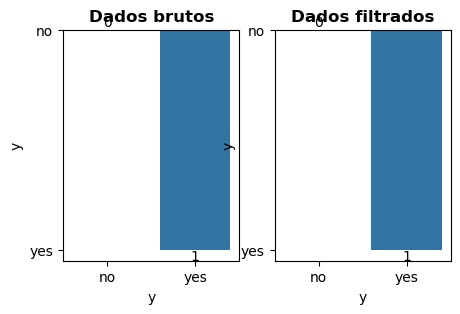

In [203]:
# # PLOTS
fig, ax = plt.subplots(1, 2, figsize = (5,3))


sns.barplot(x = bank_raw_target_perc.index,
            y = 'y',
            data = bank_raw_target_perc,
            ax = ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].set_title('Dados brutos',
                fontweight ="bold")


sns.barplot(x = bank_target_perc.index,
            y = 'y',
            data = bank_target_perc,
            ax = ax[1])
ax[1].bar_label(ax[1].containers[0])
ax[1].set_title('Dados filtrados',
                fontweight ="bold")

**Aula 2 - Parte II: Aplicação Inicial - Parte 2**

In [204]:
idades = [17,98]

In [205]:
bank.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
5,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [206]:
bank.job.unique().tolist()

['services', 'housemaid']

In [207]:
jobs_list = bank.job.unique().tolist()
jobs_list.append('all')
print('PROFISSÕES DISPONIVEIS:', jobs_list)

PROFISSÕES DISPONIVEIS: ['services', 'housemaid', 'all']


In [208]:
jobs_selected = ['all']
jobs_selected

['all']

In [209]:
bank = bank_raw.copy()
bank.shape

(100580, 21)

In [210]:
jobs_selected = jobs_list
jobs_selected = ['housemaid','services']

In [211]:
bank = bank_raw.copy()
bank.shape

(100580, 21)

In [212]:
# bank = bank[(bank['age'] >= idades[0]) & (bank['age'] <= idades[1])]

bank = bank[bank['job'].isin(jobs_selected)].reset_index(drop=True)

In [213]:
bank.shape

(100580, 21)

**Aula 2 - Parte III: Aplicação Inicial**

In [214]:
bank = bank_raw.copy()
bank.shape

(100580, 21)

In [215]:
if 'all' in jobs_selected:
    pass
else:
    bank = bank[bank['job'].isin(jobs_selected)].reset_index(drop=True)

In [216]:
bank.shape

(100580, 21)

**Aula 3: 9 Colunas como filtro**

In [217]:
bank[['age','job','marital','default','housing','loan','contact','month','day_of_week','y']]

,age,job,marital,default,housing,loan,contact,month,day_of_week,y
0,56,housemaid,married,no,no,no,telephone,may,mon,no
1,57,services,married,unknown,no,no,telephone,may,mon,no
2,37,services,married,no,yes,no,telephone,may,mon,no
3,56,services,married,no,no,yes,telephone,may,mon,no
4,45,services,married,unknown,no,no,telephone,may,mon,no
...,...,...,...,...,...,...,...,...,...,...
100575,31,housemaid,single,no,no,no,telephone,nov,mon,no
100576,31,housemaid,single,no,no,no,cellular,nov,mon,no
100577,38,housemaid,divorced,no,no,no,cellular,nov,wed,yes
100578,62,services,married,no,yes,no,cellular,nov,wed,no


In [218]:
bank.day_of_week.unique().tolist()

['mon', 'tue', 'wed', 'thu', 'fri']

**Aula 4: st.cache()**

In [219]:
bank_maior = pd.concat([bank]*20,ignore_index=True)
bank_maior

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011595,31,housemaid,single,university.degree,no,no,no,telephone,nov,mon,...,5,999,0,nonexistent,-1.1,94.767,-50.8,1.039,4963.6,no
2011596,31,housemaid,single,university.degree,no,no,no,cellular,nov,mon,...,4,999,0,nonexistent,-1.1,94.767,-50.8,1.039,4963.6,no
2011597,38,housemaid,divorced,university.degree,no,no,no,cellular,nov,wed,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.030,4963.6,yes
2011598,62,services,married,high.school,no,yes,no,cellular,nov,wed,...,5,999,0,nonexistent,-1.1,94.767,-50.8,1.030,4963.6,no


In [220]:
bank_maior.shape

(2011600, 21)

In [221]:
bank_maior.to_csv('./data/input/bank-additional-full-40.csv',index=False, sep=';')

**Aula 5: st.file_uploader()**

In [222]:
## diretamente nos códigos do streamlit

**Aula 7: st.download_button()**

In [223]:
bank = pd.read_csv("./bank-additional/bank-additional-full.csv", delimiter=';')
# se executado pelo jupyter alterar o formato da exportação do arquivo para:
# bank = pd.read_csv('./data/input/bank-additional-full.csv', sep=';')

bank.head(10)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,57,housemaid,divorced,basic.4y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,34,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,39,housemaid,married,basic.4y,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [224]:
a = bank.to_csv()
print(repr(a[:500]))  # Print only first 500 characters for testing

',age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y\r\n0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no\r\n1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no\r\n2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,no'


In [225]:
type(a)

str

In [243]:
b = a.encode('utf-8')
print(repr(b[:500]))

b',col1\r\n0,1\r\n1,2\r\n2,3\r\n'


In [244]:
type(b)

bytes

In [245]:
from io                     import BytesIO

In [246]:
pip install XlsxWriter


Note: you may need to restart the kernel to use updated packages.


In [247]:
output = BytesIO()
writer = pd.ExcelWriter(output, engine='xlsxwriter')

In [248]:
bank.to_excel(writer, index=False, sheet_name='Sheet1')

In [249]:
writer

In [250]:
writer.close()

In [251]:
processed_data = output.getvalue()

In [252]:
processed_data[:100]

b'PK\x03\x04\x14\x00\x00\x00\x08\x00\x00\x00?\x00\xf8J\xa7!Q\x01\x00\x00\x90\x04\x00\x00\x13\x00\x00\x00[Content_Types].xml\xad\x94\xcbN\xc30\x10E\xf7H\xfcC\xe4-J\xdc\xb2@\x085\xed\x82\xc7\x12*Q>\xc0\xd8\x93\xc6\xaac[\x9eii\xff\x9eI\xfa\x10 h\x8b\xdaM\xacd\xee\xdc'

In [253]:
a=bank.y.value_counts(normalize=True).to_frame(name='proportion')
a

,proportion
y,
no,0.914695
yes,0.085305


<Axes: ylabel='proportion'>

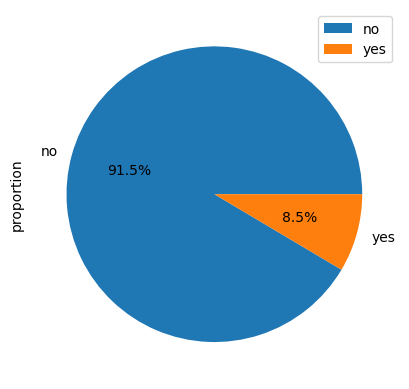

In [254]:
fig, ax = plt.subplots()
a.plot.pie(y='proportion', ax=ax, autopct='%1.1f%%')
plt.show()

<Axes: ylabel='proportion'>

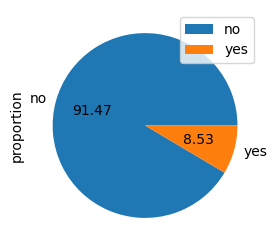

In [255]:
fig, ax = plt.subplots(1, 1, figsize = (5,3))
a.plot(kind='pie', autopct='%.2f', y='proportion', ax = ax)
plt.show()

<Axes: xlabel='y'>

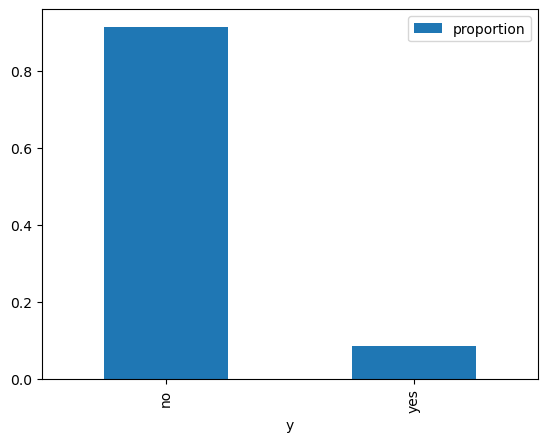

In [256]:
a.plot(kind='bar')

**Aula 7: st.collumns() e st.radio()**

In [257]:
## diretamente nos códigos do streamlit

In [258]:
df = pd.DataFrame({"col1": [1, 2, 3]})
a = df.to_csv()
a  

',col1\r\n0,1\r\n1,2\r\n2,3\r\n'

In [259]:
print(type(bank))
print(bank.shape)
print(bank.head())


<class 'pandas.core.frame.DataFrame'>
(100580, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   56   services  married  high.school       no      no  yes  telephone   
4   45   services  married     basic.9y  unknown      no   no  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   co